In [1]:
import os
import shutil
import random
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import load_img, img_to_array

print('All libraries imported successfully!')
print('TensorFlow version:', tf.__version__)


All libraries imported successfully!
TensorFlow version: 2.12.0


In [2]:
DS1_PATH = r'C:\Users\User\Desktop\Parami_Advanced_ML\Final_Project\Dataset\images'


PROCESSED_PATH = r'C:\Users\User\Desktop\Parami_Advanced_ML\Final_Project\Processed_Dataset'

print('Dataset path:', DS1_PATH)
print('Processed path:', PROCESSED_PATH)
print(f'Dataset exists: {os.path.exists(DS1_PATH)}')


Dataset path: C:\Users\User\Desktop\Parami_Advanced_ML\Final_Project\Dataset\images
Processed path: C:\Users\User\Desktop\Parami_Advanced_ML\Final_Project\Processed_Dataset
Dataset exists: True


In [3]:
all_folders = [f for f in os.listdir(DS1_PATH) 
               if os.path.isdir(os.path.join(DS1_PATH, f))]
all_folders.sort()

print(f'\nTotal classes found: {len(all_folders)}')
print('\nClass name'.ljust(25) + 'Image count')
print('-'*45)

total_images = 0
class_counts = {}

for folder in all_folders:
    folder_path = os.path.join(DS1_PATH, folder)
    
    image_count = 0
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png', '.gif', '.bmp', '.webp')):
                image_count += 1
    
    class_counts[folder] = image_count
    total_images += image_count
    print(f'{folder:<25} {image_count}')

print('-'*45)
print(f'TOTAL IMAGES: {total_images}')


Total classes found: 10

Class name              Image count
---------------------------------------------
bathroom                  249
clothing                  202
electronics               222
food_storage              225
fruits_vegetables         212
furniture                 203


medical                   221
sports                    265
stationary                187
tools                     248
---------------------------------------------
TOTAL IMAGES: 2234


In [4]:

SELECTED_CLASSES = [
    'bathroom',
    'clothing', 
    'electronics',
    'food_storage',
    'fruits_vegetables',
    'furniture',
    'medical',
    'sports',
    'stationary',
    'tools'
]


SELECTED_CLASSES = [c for c in SELECTED_CLASSES if c in class_counts]

print(f'Selected {len(SELECTED_CLASSES)} classes (ALL classes):')
print('='*50)
for cls in SELECTED_CLASSES:
    print(f'  {cls:<20} {class_counts[cls]:>5} images')
print('='*50)
total_images_selected = sum(class_counts[c] for c in SELECTED_CLASSES)
print(f'Total images to use: {total_images_selected}')

Selected 10 classes (ALL classes):
  bathroom               249 images
  clothing               202 images
  electronics            222 images
  food_storage           225 images
  fruits_vegetables      212 images
  furniture              203 images
  medical                221 images
  sports                 265 images
  stationary             187 images
  tools                  248 images
Total images to use: 2234


In [5]:
os.makedirs(PROCESSED_PATH, exist_ok=True)


for class_name in SELECTED_CLASSES:
    class_folder = os.path.join(PROCESSED_PATH, class_name)
    os.makedirs(class_folder, exist_ok=True)

print(f'  Location: {PROCESSED_PATH}')

  Location: C:\Users\User\Desktop\Parami_Advanced_ML\Final_Project\Processed_Dataset


In [6]:
def collect_all_images(folder_path):
    """Collect all image files from folder and subfolders"""
    images = []
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png', '.gif', '.bmp', '.webp')):
                images.append(os.path.join(root, file))
    return images

print('Copying images to processed dataset...')
print('='*50)

copy_summary = {}

for class_name in SELECTED_CLASSES:
    src_folder = os.path.join(DS1_PATH, class_name)
    dst_folder = os.path.join(PROCESSED_PATH, class_name)
    
    all_images = collect_all_images(src_folder)
    
    print(f'\n {class_name}:')
    print(f'   Found {len(all_images)} images')
    
    copied = 0
    failed = 0
    
    for i, img_path in enumerate(all_images):
        
        original_name = os.path.basename(img_path)
        ext = os.path.splitext(original_name)[1].lower()
        
        
        new_name = f'{class_name}_{i:05d}{ext}'
        dst_path = os.path.join(dst_folder, new_name)
        
        try:
            
            with Image.open(img_path) as img:
                img.verify()
            shutil.copy2(img_path, dst_path)
            copied += 1
        except Exception as e:
            failed += 1
            print(f'      ⚠️ Failed: {original_name} - {e}')
    
    copy_summary[class_name] = {'copied': copied, 'failed': failed}
    print(f'   ✓ Copied: {copied}, Failed: {failed}')


Copying images to processed dataset...

 bathroom:
   Found 249 images


   ✓ Copied: 249, Failed: 0

 clothing:
   Found 202 images
   ✓ Copied: 202, Failed: 0

 electronics:
   Found 222 images
   ✓ Copied: 222, Failed: 0

 food_storage:
   Found 225 images
   ✓ Copied: 225, Failed: 0

 fruits_vegetables:
   Found 212 images
   ✓ Copied: 212, Failed: 0

 furniture:
   Found 203 images
   ✓ Copied: 203, Failed: 0

 medical:
   Found 221 images
   ✓ Copied: 221, Failed: 0

 sports:
   Found 265 images
   ✓ Copied: 265, Failed: 0

 stationary:
   Found 187 images
   ✓ Copied: 187, Failed: 0

 tools:
   Found 248 images
   ✓ Copied: 248, Failed: 0


In [7]:
total_copied = 0
for class_name, stats in copy_summary.items():
    total_copied += stats['copied']
    print(f'{class_name:<20} {stats["copied"]:>5} images')
print('-'*50)
print(f'{"TOTAL":<20} {total_copied:>5} images')


bathroom               249 images
clothing               202 images
electronics            222 images
food_storage           225 images
fruits_vegetables      212 images
furniture              203 images
medical                221 images
sports                 265 images
stationary             187 images
tools                  248 images
--------------------------------------------------
TOTAL                 2234 images


In [8]:
for class_name in SELECTED_CLASSES:
    class_folder = os.path.join(PROCESSED_PATH, class_name)
    num_images = len([f for f in os.listdir(class_folder) 
                     if f.lower().endswith(('.jpg', '.jpeg', '.png', '.gif', '.bmp', '.webp'))])
    print(f'{class_name:<20} {num_images:>5} images')


bathroom               249 images
clothing               202 images
electronics            222 images
food_storage           225 images
fruits_vegetables      212 images
furniture              203 images
medical                221 images
sports                 265 images
stationary             187 images
tools                  248 images



Sample images from processed dataset:


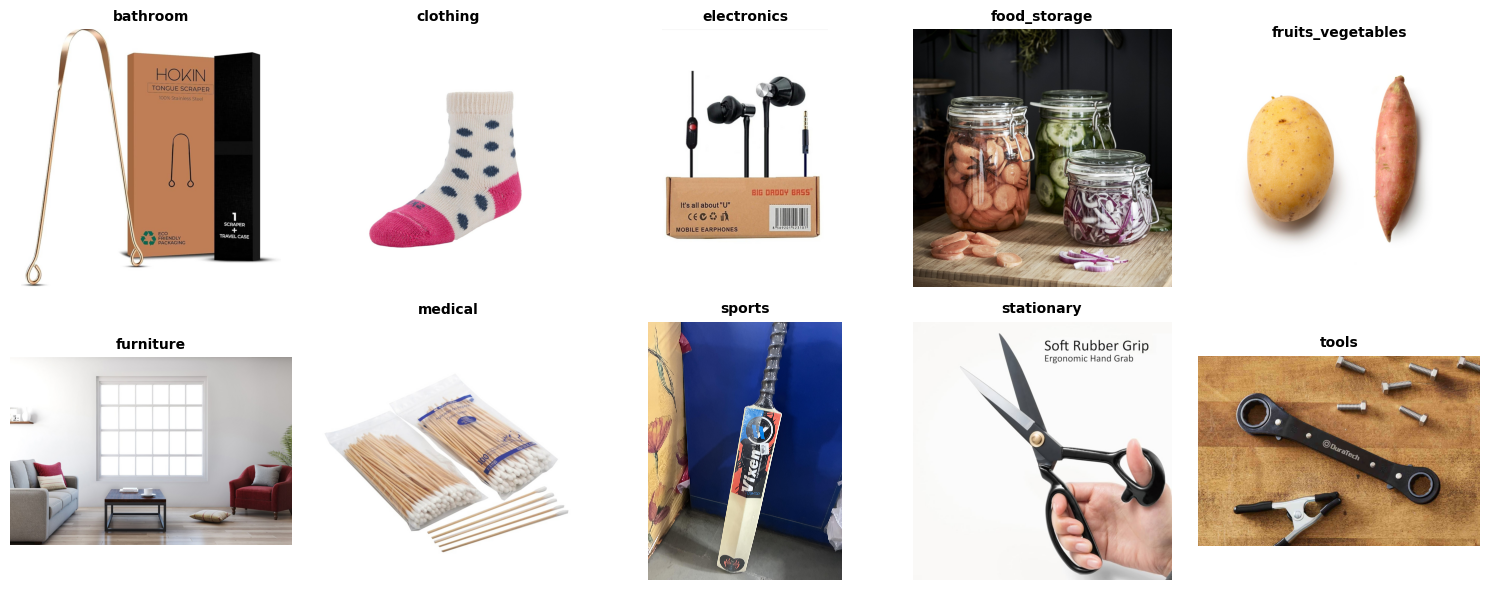

In [9]:
print('\nSample images from processed dataset:')
num_to_show = min(10, len(SELECTED_CLASSES))
rows = (num_to_show + 4) // 5
fig, axes = plt.subplots(rows, 5, figsize=(15, rows*3))
axes = axes.flatten() if rows > 1 else [axes] if num_to_show == 1 else axes

for i in range(num_to_show):
    class_name = SELECTED_CLASSES[i]
    class_folder = os.path.join(PROCESSED_PATH, class_name)
    images = [f for f in os.listdir(class_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    if images:
        sample_img = random.choice(images)
        img_path = os.path.join(class_folder, sample_img)
        img = mpimg.imread(img_path)
        axes[i].imshow(img)
        axes[i].set_title(class_name, fontweight='bold', fontsize=10)
        axes[i].axis('off')


for j in range(num_to_show, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()



In [10]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 25
SEED = 42

print(f'Image size: {IMG_SIZE}')
print(f'Batch size: {BATCH_SIZE}')
print(f'Epochs: {EPOCHS}')
print(f'Number of classes: {len(SELECTED_CLASSES)}')

Image size: (224, 224)
Batch size: 32
Epochs: 25
Number of classes: 10


In [11]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    PROCESSED_PATH,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)


Found 2234 files belonging to 10 classes.
Using 1788 files for training.


In [12]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    PROCESSED_PATH,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 2234 files belonging to 10 classes.
Using 446 files for validation.


In [13]:
CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)

print(f'\nClasses: {CLASS_NAMES}')
print(f'Number of classes: {NUM_CLASSES}')


Classes: ['bathroom', 'clothing', 'electronics', 'food_storage', 'fruits_vegetables', 'furniture', 'medical', 'sports', 'stationary', 'tools']
Number of classes: 10


In [14]:
normalization_layer = layers.Rescaling(1./255)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])


In [15]:
train_ds = train_ds.map(lambda x, y: (data_augmentation(normalization_layer(x)), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# Optimize loading
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print('Data preprocessing complete!')

Data preprocessing complete!


In [16]:
from tensorflow.keras.applications import MobileNetV2


base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False


inputs = keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = keras.Model(inputs, outputs)

In [17]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.00001,
    verbose=1
)


In [19]:
print('Starting training...')
print(f'Total images: {total_copied}')
print(f'Training batches: {len(train_ds)}')
print(f'Validation batches: {len(val_ds)}')
print('='*50)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint, reduce_lr]
)


Starting training...
Total images: 2234
Training batches: 56
Validation batches: 14
Epoch 1/25
56/56 [==============================] - ETA: 0s - loss: 2.1155 - accuracy: 0.2612
Epoch 1: val_accuracy improved from -inf to 0.52915, saving model to best_model.h5
56/56 [==============================] - 73s 1s/step - loss: 2.1155 - accuracy: 0.2612 - val_loss: 1.5603 - val_accuracy: 0.5291 - lr: 0.0010
Epoch 2/25
56/56 [==============================] - ETA: 0s - loss: 1.5137 - accuracy: 0.4877
Epoch 2: val_accuracy improved from 0.52915 to 0.62556, saving model to best_model.h5
56/56 [==============================] - 52s 926ms/step - loss: 1.5137 - accuracy: 0.4877 - val_loss: 1.1853 - val_accuracy: 0.6256 - lr: 0.0010
Epoch 3/25
56/56 [==============================] - ETA: 0s - loss: 1.1645 - accuracy: 0.5928
Epoch 3: val_accuracy improved from 0.62556 to 0.65919, saving model to best_model.h5
56/56 [==============================] - 39s 700ms/step - loss: 1.1645 - accuracy: 0.5928 - 

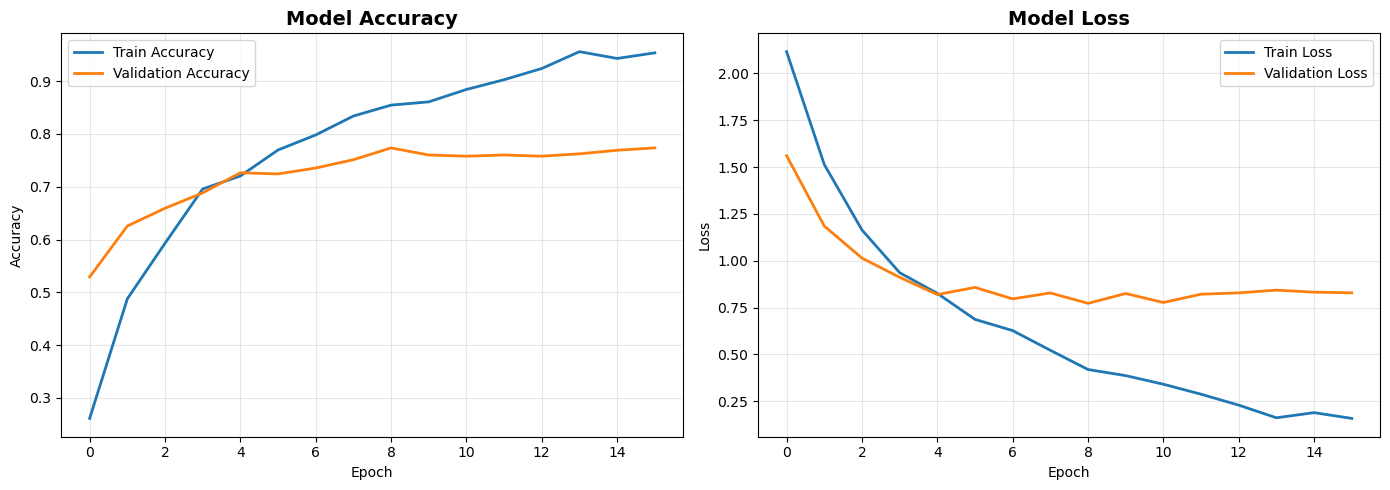

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax1.set_title('Model Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'], label='Train Loss', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax2.set_title('Model Loss', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
best_val_acc = max(history.history['val_accuracy'])
best_epoch = history.history['val_accuracy'].index(best_val_acc) + 1
print(f'\nBest Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}')



Best Validation Accuracy: 77.35% at epoch 9


In [22]:
model.save('assistvision_model.keras')

In [23]:

print("PHASE 2 — FINE-TUNING")


best_p1 = max(history.history['val_accuracy'])
base_model.trainable = True


for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f"\nTotal base model layers: {len(base_model.layers)}")

trainable_layers = sum([1 for layer in base_model.layers if layer.trainable])

print(f"Trainable layers after unfreezing: {trainable_layers}")


model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

print("\nModel recompiled for fine-tuning!")


ft_early_stop = EarlyStopping(

    monitor='val_accuracy',

    patience=6,

    restore_best_weights=True,

    verbose=1
)

ft_checkpoint = ModelCheckpoint(

    'best_model_finetuned.keras',

    monitor='val_accuracy',

    save_best_only=True,

    verbose=1
)

ft_reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.5,

    patience=3,

    min_lr=1e-7,

    verbose=1
)


history_ft = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=15,

    callbacks=[
        ft_early_stop,
        ft_checkpoint,
        ft_reduce_lr
    ]
)


best_p2 = max(history_ft.history['val_accuracy'])

print("FINE-TUNING RESULTS")


print(f"Phase 1 best accuracy : {best_p1*100:.2f}%")

print(f"Phase 2 best accuracy : {best_p2*100:.2f}%")

print(f"Improvement           : +{(best_p2 - best_p1)*100:.2f}%")

PHASE 2 — FINE-TUNING

Total base model layers: 154
Trainable layers after unfreezing: 30

Model recompiled for fine-tuning!
Epoch 1/15
56/56 [==============================] - ETA: 0s - loss: 0.3720 - accuracy: 0.8714
Epoch 1: val_accuracy improved from -inf to 0.76233, saving model to best_model_finetuned.keras
56/56 [==============================] - 47s 764ms/step - loss: 0.3720 - accuracy: 0.8714 - val_loss: 0.7675 - val_accuracy: 0.7623 - lr: 1.0000e-05
Epoch 2/15
56/56 [==============================] - ETA: 0s - loss: 0.2984 - accuracy: 0.9105
Epoch 2: val_accuracy improved from 0.76233 to 0.78027, saving model to best_model_finetuned.keras
56/56 [==============================] - 44s 787ms/step - loss: 0.2984 - accuracy: 0.9105 - val_loss: 0.7591 - val_accuracy: 0.7803 - lr: 1.0000e-05
Epoch 3/15
56/56 [==============================] - ETA: 0s - loss: 0.2721 - accuracy: 0.9083
Epoch 3: val_accuracy did not improve from 0.78027
56/56 [==============================] - 42s 759m

In [26]:
import json

with open('class_names.json', 'w') as f:
    json.dump(CLASS_NAMES, f)


with open('training_history.json', 'w') as f:
    json.dump({
        'accuracy': history.history['accuracy'],
        'val_accuracy': history.history['val_accuracy'],
        'loss': history.history['loss'],
        'val_loss': history.history['val_loss']
    }, f)


In [25]:
model.save('assistvision_model.keras')